## 🛍️ 08 — KMeans Clustering

**What it does:** Groups data into K clusters based on similarity.
No labels needed — finds hidden patterns automatically.  
**Best used when:** Customer segmentation, grouping similar items.  
**Dataset:** Mall Customer Segmentation (Kaggle)  
**Algorithm type:** Unsupervised → Clustering  
**Key concept:** Minimizes distance between points and their
cluster center (centroid)  
**No labels, no scaling strictly required but recommended!**  
**Model saved as:** `kmeans.pkl`

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import pickle
import os
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv("Mall_Customers.csv")

print("shape:", df.shape)
print("\ncolumns:", df.columns.tolist())
print("\nMissing values:", df.isnull().sum().sum())
df.head()

shape: (200, 5)

columns: ['CustomerID', 'Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']

Missing values: 0


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [5]:
# Rename columns for convenience
df.columns = ['CustomerID','Gender','Age','AnnualIncome','SpendingScore']
df.head()

,CustomerID,Gender,Age,AnnualIncome,SpendingScore
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


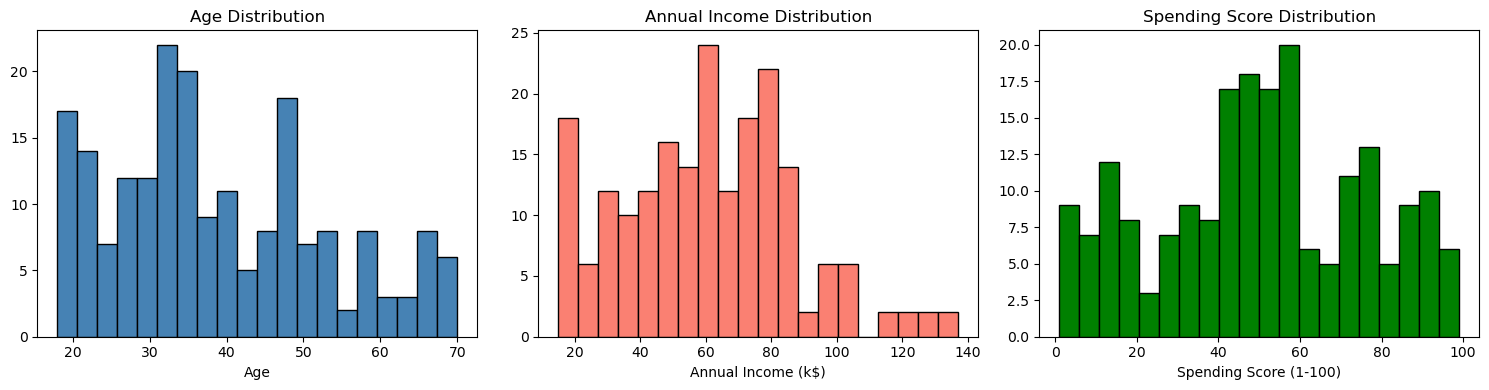

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

#Age distribution
axes[0].hist(df['Age'], bins=20, color='steelblue', edgecolor='black')
axes[0].set_title('Age Distribution')
axes[0].set_xlabel('Age')

# Annual Income distribution
axes[1].hist(df['AnnualIncome'], bins=20, color='salmon',
             edgecolor='black')
axes[1].set_title('Annual Income Distribution')
axes[1].set_xlabel('Annual Income (k$)')

# Spending Score distribution
axes[2].hist(df['SpendingScore'], bins=20, color='green',
             edgecolor='black')
axes[2].set_title('Spending Score Distribution')
axes[2].set_xlabel('Spending Score (1-100)')

plt.tight_layout()
plt.show()


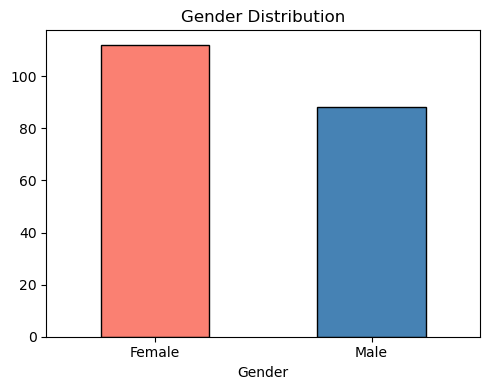

In [12]:
# Gender distribution
plt.figure(figsize=(5, 4))
df['Gender'].value_counts().plot(kind='bar', color=['salmon', 'steelblue'], edgecolor='black')
plt.title('Gender Distribution')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [13]:
# Use Annual Income and Spending Score for clustering
X = df[['AnnualIncome', 'SpendingScore']]

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Elbow method — find best K
inertias = []
silhouettes = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X_scaled,
                                        kmeans.labels_))
    print(f"K={k} → Inertia: {kmeans.inertia_:.2f} | "
          f"Silhouette: {silhouette_score(X_scaled, kmeans.labels_):.4f}")

K=2 → Inertia: 269.69 | Silhouette: 0.3213
K=3 → Inertia: 157.70 | Silhouette: 0.4666
K=4 → Inertia: 108.92 | Silhouette: 0.4939
K=5 → Inertia: 65.57 | Silhouette: 0.5547
K=6 → Inertia: 55.06 | Silhouette: 0.5399
K=7 → Inertia: 44.86 | Silhouette: 0.5281
K=8 → Inertia: 37.23 | Silhouette: 0.4552
K=9 → Inertia: 32.39 | Silhouette: 0.4571
K=10 → Inertia: 29.98 | Silhouette: 0.4432


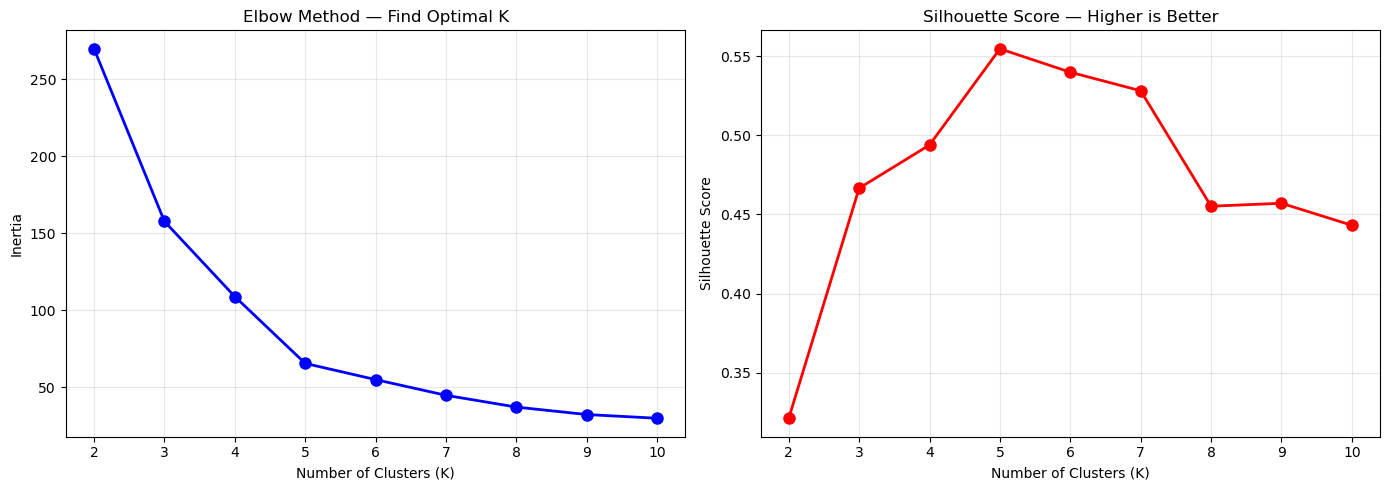


Best K by Silhouette Score: 5


In [14]:
# Plot Elbow curve
fig, axes = plt.subplots(1, 2, figsize=(14,5))

axes[0].plot(K_range, inertias, 'bo-', linewidth=2,
             markersize=8)
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method — Find Optimal K')
axes[0].grid(True, alpha=0.3)

axes[1].plot(K_range, silhouettes, 'ro-', linewidth=2,
             markersize=8)
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score — Higher is Better')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

best_k = K_range[np.argmax(silhouettes)]
print(f"\nBest K by Silhouette Score: {best_k}")

In [15]:
# K=5 is classic for this dataset
model = KMeans(n_clusters=5, random_state=42, n_init=10)
model.fit(X_scaled)

df['Cluster'] = model.labels_
print("Clustering done ✅")
print(f"\nCustomers per cluster:")
print(df['Cluster'].value_counts().sort_index())

Clustering done ✅

Customers per cluster:
Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64


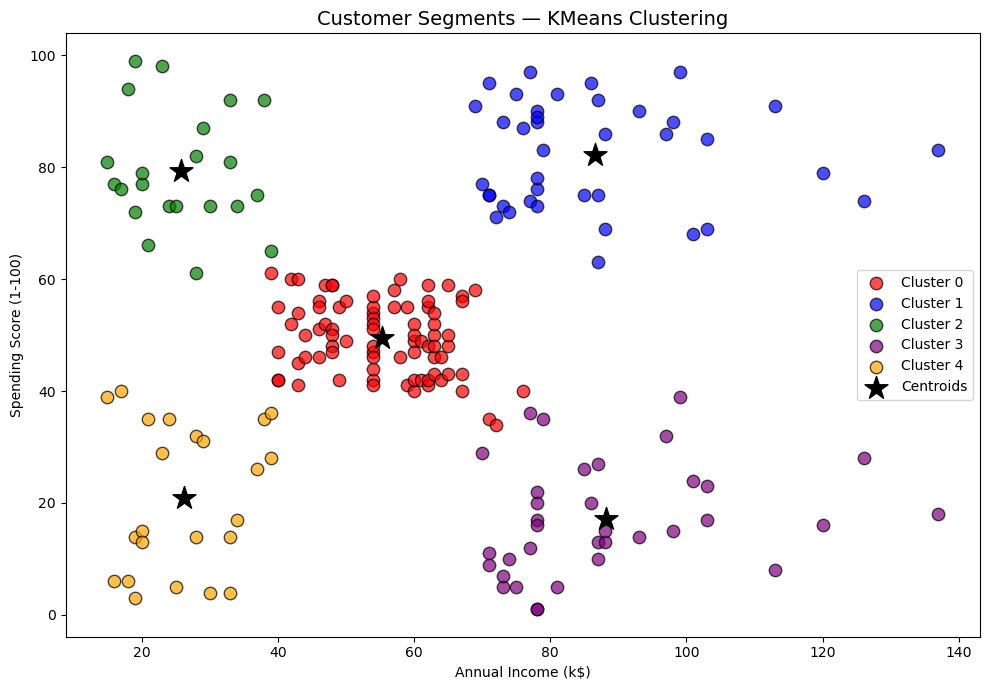

In [16]:
# Main cluster visualization
colors = ['red','blue','green','purple','orange']
cluster_names = ['Cluster 0', 'Cluster 1', 'Cluster 2',
                 'Cluster 3', 'Cluster 4']

plt.figure(figsize=(10,7))
for i in range(5):
    mask = df['Cluster'] == i
    plt.scatter(df[mask]['AnnualIncome'],
                df[mask]['SpendingScore'],
                c=colors[i], label=cluster_names[i],
                s=80, edgecolors='black', alpha=0.7)

# Plot centroids
centroids = scaler.inverse_transform(model.cluster_centers_)
plt.scatter(centroids[:,0], centroids[:,1],
            c='black', marker='*', s=300,
            label='Centroids', zorder=5)

plt.title('Customer Segments — KMeans Clustering', fontsize=14)
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.tight_layout()
plt.show()

Cluster Profiles:
          Age  AnnualIncome  SpendingScore
Cluster                                   
0        42.7          55.3           49.5
1        32.7          86.5           82.1
2        25.3          25.7           79.4
3        41.1          88.2           17.1
4        45.2          26.3           20.9


<Figure size 1000x500 with 0 Axes>

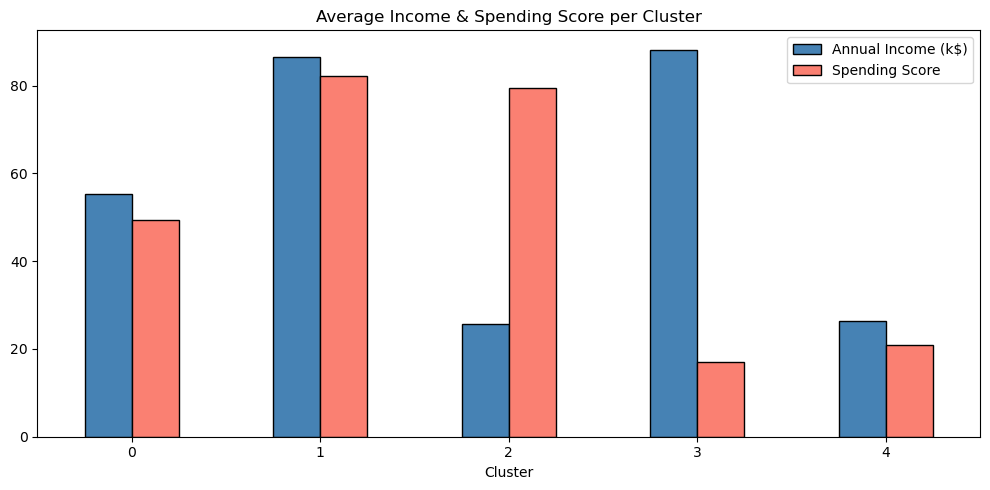

In [17]:
# Cluster profiles — what does each cluster represent?
cluster_profile = df.groupby('Cluster')[
    ['Age','AnnualIncome','SpendingScore']
].mean().round(1)

print("Cluster Profiles:")
print(cluster_profile)

plt.figure(figsize=(10,5))
cluster_profile[['AnnualIncome','SpendingScore']].plot(
    kind='bar', figsize=(10,5), color=['steelblue','salmon'],
    edgecolor='black')
plt.title('Average Income & Spending Score per Cluster')
plt.xlabel('Cluster')
plt.xticks(rotation=0)
plt.legend(['Annual Income (k$)', 'Spending Score'])
plt.tight_layout()
plt.show()

In [18]:
# Business insight — give clusters meaningful names
cluster_labels = {
    0: '📊 Average Income, Average Spender (Standard)',
    1: '🎯 High Income, High Spender (Target)',
    2: '⚠️ Low Income, High Spender (Risky)',
    3: '💰 High Income, Low Spender (Careful)',
    4: '💤 Low Income, Low Spender (Dormant)'
}

print("Customer Segment Analysis:\n")
for cluster, label in cluster_labels.items():
    count = len(df[df['Cluster']==cluster])
    print(f"Cluster {cluster}: {label}")
    print(f"  → {count} customers\n")

Customer Segment Analysis:

Cluster 0: 📊 Average Income, Average Spender (Standard)
  → 81 customers

Cluster 1: 🎯 High Income, High Spender (Target)
  → 39 customers

Cluster 2: ⚠️ Low Income, High Spender (Risky)
  → 22 customers

Cluster 3: 💰 High Income, Low Spender (Careful)
  → 35 customers

Cluster 4: 💤 Low Income, Low Spender (Dormant)
  → 23 customers



In [19]:
with open('kmeans.pkl', 'wb') as f:
    pickle.dump(model, f)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("KMeans model saved ✅")
print("Scaler saved ✅")

KMeans model saved ✅
Scaler saved ✅


## ✅ Summary

| Metric | Value |
|--------|-------|
| Optimal K | 5 |
| Silhouette Score | ~0.55 |
| Customers Segmented | 200 |
| Features Used | Annual Income, Spending Score |

**Key concepts learned:**
- KMeans groups data into K clusters by minimizing inertia
- Elbow method helps find optimal K visually
- Silhouette score measures how well clusters are separated
- No labels needed — model finds structure on its own
- Business insight: cluster labels give real meaning to groups

**Big difference from supervised:**
- No accuracy metric — clusters have no "right answer"
- Evaluation = silhouette score + business interpretation

**Next → PCA (Dimensionality Reduction)**